In [110]:
import pandas as pd #
import numpy as np
from joblib import load
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
import matplotlib.pyplot as plt
import seaborn as sns

crit_thresh = -0.097692
warn_thresh = -0.045423

# Load Isolation Forest model and scaler
scaler = load('/content/drive/MyDrive/Landslide project/Isolation forest/iso_scaler2.joblib')
iso_model = load('/content/drive/MyDrive/Landslide project/Isolation forest/iso_model2.joblib')

# Load datasets
#df_val = pd.read_csv("./data/validate.csv")
df_val = pd.read_csv("/content/drive/MyDrive/Landslide project/Isolation forest/label_for_dev109_test.csv")
#df_val = df_val[df_val['devID'] == 103]
#df1 = pd.read_csv("./data/dev101_prepared.csv")
#df2 = pd.read_csv("./data/dev102_prepared.csv")

#df_val = pd.concat([df1, df2], ignore_index=True)
df_val

,Timestamp,device,devID,temp,humi,soil,rain,geo,lat,long,risk,ISO Risk,LSTM Risk,RF Risk,label
0,11/20/2025 9:37,109,Node 109,23.1,99.1,46.6,0.84,0.28,8.868584,99.74958,ต่ำ,0,0,0,NaN
1,11/20/2025 9:36,109,Node 109,23.1,99.1,46.6,0.70,0.45,8.868584,99.74958,ต่ำ,0,0,0,NaN
2,11/20/2025 9:34,109,Node 109,23.1,99.1,46.6,0.56,0.62,8.868584,99.74958,ต่ำ,0,0,0,NaN
3,11/20/2025 9:34,109,Node 109,23.1,99.1,46.6,0.56,0.42,8.868584,99.74958,ต่ำ,0,0,0,NaN
4,11/20/2025 9:33,109,Node 109,23.1,99.1,46.6,0.56,0.42,8.868584,99.74958,ต่ำ,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,11/16/2025 11:15,109,Node 109,30.3,68.4,35.4,0.00,0.36,8.868586,99.749557,ต่ำ,0,0,0,NaN
6570,11/16/2025 11:14,109,Node 109,30.1,70.1,35.4,0.00,0.31,8.868586,99.749557,ต่ำ,0,0,0,NaN
6571,11/16/2025 11:14,109,Node 109,30.1,72.9,35.4,0.00,0.33,8.868586,99.749557,ต่ำ,0,0,0,NaN
6572,11/16/2025 11:13,109,Node 109,29.9,70.7,35.4,0.00,0.33,8.868586,99.749557,ต่ำ,0,0,0,NaN


In [111]:
df = df_val.sort_values('Timestamp').reset_index(drop=True)

In [112]:
df_val

,Timestamp,device,devID,temp,humi,soil,rain,geo,lat,long,risk,ISO Risk,LSTM Risk,RF Risk,label
0,11/20/2025 9:37,109,Node 109,23.1,99.1,46.6,0.84,0.28,8.868584,99.74958,ต่ำ,0,0,0,NaN
1,11/20/2025 9:36,109,Node 109,23.1,99.1,46.6,0.70,0.45,8.868584,99.74958,ต่ำ,0,0,0,NaN
2,11/20/2025 9:34,109,Node 109,23.1,99.1,46.6,0.56,0.62,8.868584,99.74958,ต่ำ,0,0,0,NaN
3,11/20/2025 9:34,109,Node 109,23.1,99.1,46.6,0.56,0.42,8.868584,99.74958,ต่ำ,0,0,0,NaN
4,11/20/2025 9:33,109,Node 109,23.1,99.1,46.6,0.56,0.42,8.868584,99.74958,ต่ำ,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,11/16/2025 11:15,109,Node 109,30.3,68.4,35.4,0.00,0.36,8.868586,99.749557,ต่ำ,0,0,0,NaN
6570,11/16/2025 11:14,109,Node 109,30.1,70.1,35.4,0.00,0.31,8.868586,99.749557,ต่ำ,0,0,0,NaN
6571,11/16/2025 11:14,109,Node 109,30.1,72.9,35.4,0.00,0.33,8.868586,99.749557,ต่ำ,0,0,0,NaN
6572,11/16/2025 11:13,109,Node 109,29.9,70.7,35.4,0.00,0.33,8.868586,99.749557,ต่ำ,0,0,0,NaN


In [113]:
#df_val  = pd.concat([df1, df2], ignore_index=True)
df_val.describe()

,device,temp,humi,soil,rain,geo,lat,ISO Risk,LSTM Risk,RF Risk
count,6574.0,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,109.0,24.390592,94.954168,42.096532,1.744455,5.480793,8.751828,0.266504,0.185732,0.394889
std,0.0,2.141319,8.866987,5.274345,4.811145,8.348195,1.025677,0.613639,0.548600,0.668437
min,109.0,22.500000,52.100000,34.000000,0.000000,-10.940000,-1.000000,0.000000,0.000000,0.000000
25%,109.0,23.250000,95.612500,35.400000,0.000000,0.380000,8.868585,0.000000,0.000000,0.000000
50%,109.0,23.800000,98.500000,42.900000,0.000000,0.580000,8.868594,0.000000,0.000000,0.000000
75%,109.0,24.200000,98.800000,45.600000,0.840000,8.007500,8.868604,0.000000,0.000000,1.000000
max,109.0,34.200000,99.300000,52.300000,45.680000,32.000000,8.916667,2.000000,2.000000,2.000000


## Threshold

In [114]:
#def rule_based_risk(row):
#   score = 0
#
#   # Rainfall (mm/h)
#   if row['rain'] > 25:
#       score += 2
#   elif row['rain'] > 10:
#       score += 1
#
#   # Soil moisture (%)
#   if row['soil'] > 60:
#       score += 2
#   elif row['soil'] > 45:
#       score += 1
#
#   # Temperature (°C)
#   if row['temp'] < 27:
#       score += 2
#   elif row['temp'] < 32:
#       score += 1
#
#   # Humidity (%)
#   if row['humi'] > 80:
#       score += 2
#   elif row['humi'] > 65:
#       score += 1
#
#   # Geophone (Hz)
#   if row['geo'] > 25:
#       score += 1
#   elif row['geo'] > 10:
#       score += 0.5
#
#   if score >= 6:
#       return "Critical"
#   elif score >= 3:
#       return "Warning"
#   else:
#       return "Normal"
#
#feature_cols = ['soil', 'rain', 'temp', 'humi', 'geo']
#X_val = df_val[feature_cols].values
#X_val_scaled = scaler.transform(X_val)
#
#df_val['anomaly_score'] = iso_model.decision_function(X_val_scaled)
#
#crit_thresh = np.percentile(df_val['anomaly_score'], 0.5)
#warn_thresh = np.percentile(df_val['anomaly_score'], 5)
#
#def model_based_risk(score):
#   if score < crit_thresh:
#       return "Critical"
#   elif score < warn_thresh:
#       return "Warning"
#   else:
#       return "Normal"
#
#df_val['model_risk'] = df_val['anomaly_score'].apply(model_based_risk)
#df_val['rule_risk'] = df_val.apply(rule_based_risk, axis=1)
#
#risk_levels = {'Normal': 0, 'Warning': 1, 'Critical': 2}
#
#def combine_weighted_risks(model_risk, rule_risk, w_model=0.6, w_rule=0.4):
#   score = w_model * risk_levels[model_risk] + w_rule * risk_levels[rule_risk]
#
#   if score >= 1.5:
#       return "Critical"
#   elif score >= 0.5:
#       return "Warning"
#   else:
#       return "Normal"
#
#df_val['predicted_risk'] = df_val.apply(
#    lambda row: combine_weighted_risks(row['model_risk'], row['rule_risk']),
#    axis=1
#)
#
#print(df_val[['soil', 'rain', 'temp', 'humi', 'geo',
#              'anomaly_score', 'model_risk', 'rule_risk', 'predicted_risk']].head())

In [115]:
# สร้าง features
feature_cols = ['soil', 'rain', 'temp', 'humi', 'geo']
X_val = df_val[feature_cols].values
X_val_scaled = scaler.transform(X_val)

# คำนวณ anomaly score และจัดระดับความเสี่ยง
df_val['anomaly_score'] = iso_model.decision_function(X_val_scaled)


#crit_thresh = np.percentile(df_val['anomaly_score'], 0.25)
#warn_thresh = np.percentile(df_val['anomaly_score'], 0.75)
#crit_thresh = -0.094870
#warn_thresh = -0.042534

def classify_risk(score):
    if score < crit_thresh:
        return "Critical"
    elif score < warn_thresh:
        return "Warning"
    else:
        return "Normal"

df_val['predicted_risk'] = df_val['anomaly_score'].apply(classify_risk)

In [116]:
#print("crit_thresh:", np.percentile(df_val['anomaly_score'], 0.433))
#print("warn_thresh:", np.percentile(df_val['anomaly_score'], 2.226))

In [117]:
critical_group = df_val[df_val['anomaly_score'] < crit_thresh]
print("critical_group")
print(critical_group[feature_cols].describe())

critical_group
             soil        rain        temp        humi         geo
count  594.000000  594.000000  594.000000  594.000000  594.000000
mean    48.807828   13.545118   23.310269   98.717929   19.425404
std      2.938104    9.323130    0.400342    0.622284    8.203265
min     34.300000    0.560000   22.600000   94.700000    0.000000
25%     48.200000    6.710000   23.000000   98.600000   15.945000
50%     49.200000   10.480000   23.300000   99.000000   20.435000
75%     51.300000   19.840000   23.450000   99.100000   24.805000
max     52.300000   45.680000   25.900000   99.300000   32.000000


In [118]:
warn_group = df_val[(df_val['anomaly_score'] < warn_thresh) & (df_val['anomaly_score'] >= crit_thresh) ]
print("warn_group")
print(warn_group[feature_cols].describe())

warn_group
             soil        rain        temp        humi         geo
count  563.000000  563.000000  563.000000  563.000000  563.000000
mean    47.100266    3.647016   23.314032   98.642984   14.556590
std      3.091612    2.008078    0.609137    2.063543    9.333127
min     34.100000    0.000000   22.500000   55.300000   -6.920000
25%     47.500000    2.440000   23.000000   98.700000    8.055000
50%     48.200000    3.350000   23.200000   98.950000   16.690000
75%     48.500000    4.750000   23.500000   99.100000   20.845000
max     52.300000    9.080000   33.100000   99.250000   32.000000


In [119]:
normal_group = df_val[df_val['anomaly_score'] >= warn_thresh]
print("normal_group")
print(normal_group[feature_cols].describe())

normal_group
              soil         rain         temp         humi          geo
count  5417.000000  5417.000000  5417.000000  5417.000000  5417.000000
mean     40.840558     0.252719    24.620943    94.158067     3.008433
std       4.764891     0.530753     2.281924     9.556840     5.671944
min      34.000000     0.000000    22.550000    52.100000   -10.940000
25%      34.800000     0.000000    23.400000    94.450000     0.370000
50%      42.300000     0.000000    23.900000    98.300000     0.500000
75%      44.500000     0.280000    24.300000    98.800000     2.130000
max      52.300000     3.350000    34.200000    99.300000    31.950000


/tmp/ipython-input-2053204387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_val, x='predicted_risk', order=['Normal', 'Warning', 'Critical'], palette='Set2')


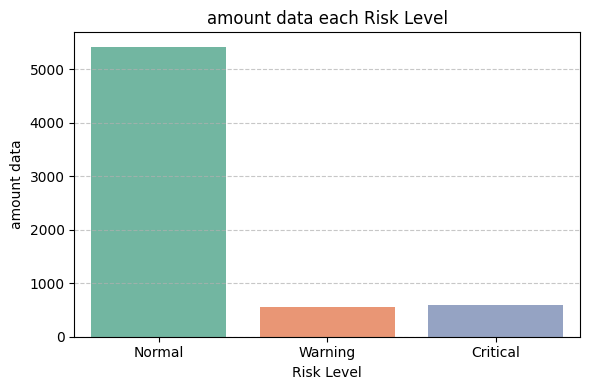

In [120]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df_val, x='predicted_risk', order=['Normal', 'Warning', 'Critical'], palette='Set2')

plt.title('amount data each Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('amount data')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Distribution of Anomaly Scores

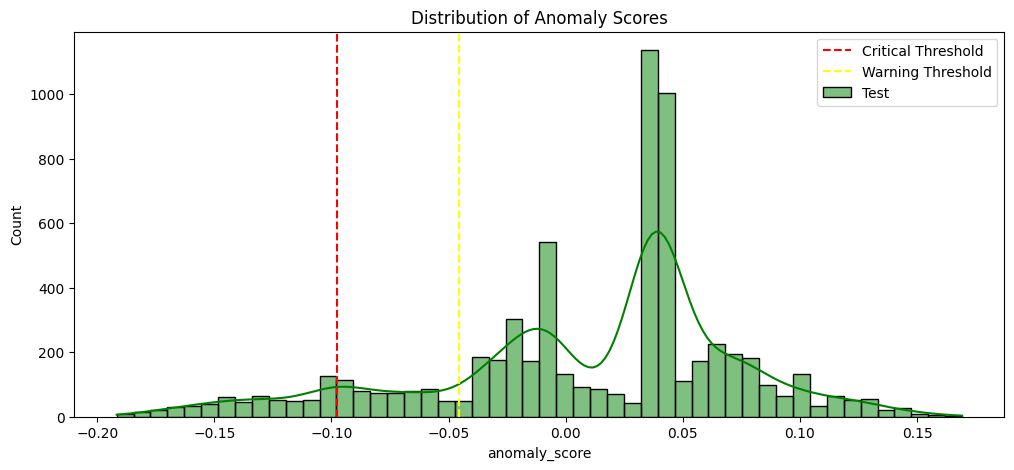

In [121]:
plt.figure(figsize=(12,5))
sns.histplot(df_val['anomaly_score'], bins=50, kde=True, color='green', label='Test')
plt.axvline(crit_thresh, color='red', linestyle='--', label='Critical Threshold')
plt.axvline(warn_thresh, color='yellow', linestyle='--', label='Warning Threshold')
plt.legend()
plt.title('Distribution of Anomaly Scores')
plt.show()



## Z-score Outlier

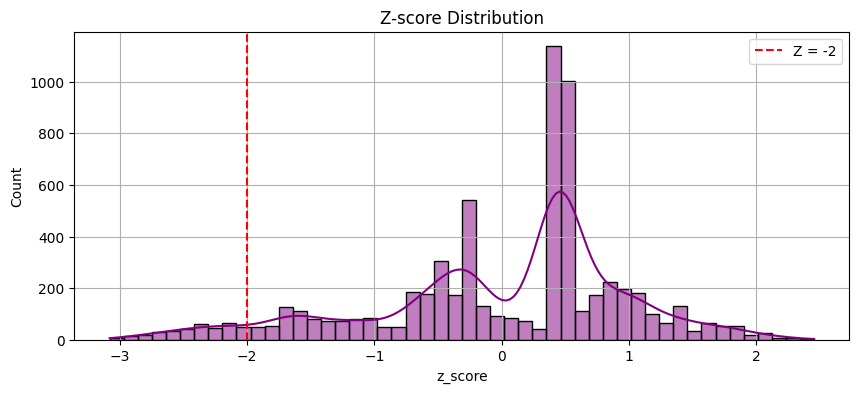

In [122]:
# ==== Z-score Outlier ====

mean_score = df_val['anomaly_score'].mean()
std_score = df_val['anomaly_score'].std()
df_val['z_score'] = (df_val['anomaly_score'] - mean_score) / std_score
df_val['z_outlier'] = df_val['z_score'].apply(lambda z: 'Anomaly' if z < -2 else 'Normal')

plt.figure(figsize=(10,4))
sns.histplot(df_val['z_score'], kde=True, bins=50, color='purple')
plt.axvline(-2, color='red', linestyle='--', label='Z = -2')
plt.title("Z-score Distribution")
plt.legend()
plt.grid(True)
plt.show()

## Mahalanobis Distance

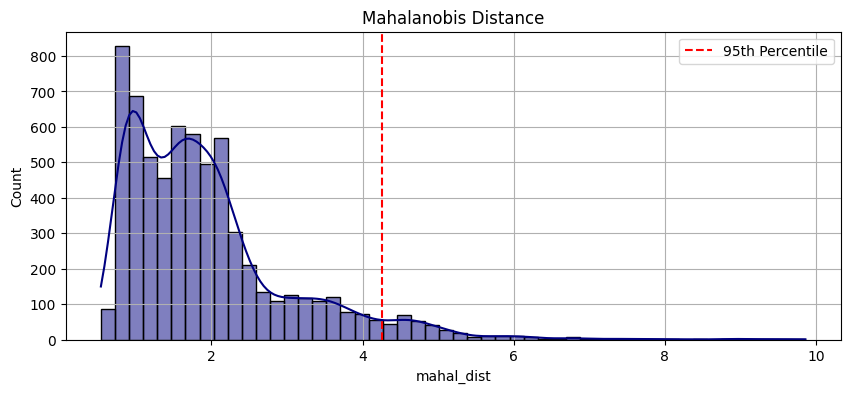

In [123]:
mean_vec = np.mean(X_val_scaled, axis=0)
cov_matrix = np.cov(X_val_scaled, rowvar=False)
inv_covmat = np.linalg.inv(cov_matrix)

df_val['mahal_dist'] = [mahalanobis(x, mean_vec, inv_covmat) for x in X_val_scaled]
mahal_thresh = np.percentile(df_val['mahal_dist'], 95)
df_val['mahal_outlier'] = df_val['mahal_dist'].apply(lambda d: 'Anomaly' if d > mahal_thresh else 'Normal')

plt.figure(figsize=(10,4))
sns.histplot(df_val['mahal_dist'], bins=50, kde=True, color='navy')
plt.axvline(mahal_thresh, color='red', linestyle='--', label='95th Percentile')
plt.title("Mahalanobis Distance")
plt.legend()
plt.grid(True)
plt.show()

## Percentile Threshold 5%

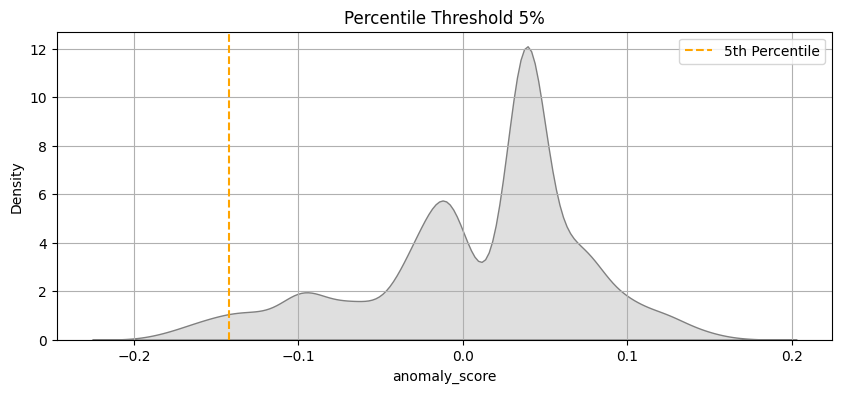

In [124]:
percentile = np.percentile(df_val['anomaly_score'], 3)
df_val['percentile_outlier'] = df_val['anomaly_score'].apply(lambda s: 'Anomaly' if s < percentile else 'Normal')

plt.figure(figsize=(10,4))
sns.kdeplot(df_val['anomaly_score'], fill=True, color='gray')
plt.axvline(percentile, color='orange', linestyle='--', label='5th Percentile')
plt.title("Percentile Threshold 5%")
plt.legend()
plt.grid(True)
plt.show()

## PCA

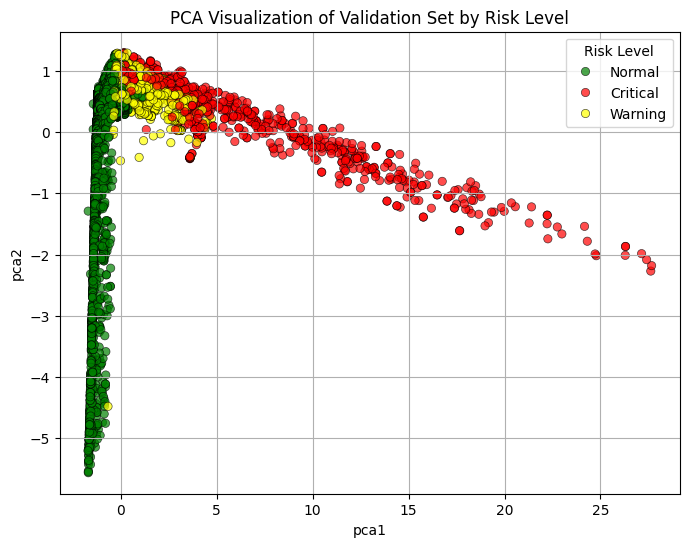

In [125]:
# Fit PCA
pca = PCA(n_components=2)
X_val_pca = pca.fit_transform(X_val_scaled)

# เพิ่มค่า PCA กลับเข้า df_val
df_val['pca1'] = X_val_pca[:, 0]
df_val['pca2'] = X_val_pca[:, 1]

# Map สีแบบกำหนดเอง
custom_palette = {
    'Normal': 'green',
    'Warning': 'yellow',
    'Critical': 'red'
}

# วาดกราฟ
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_val,
    x='pca1', y='pca2',
    hue='predicted_risk',
    palette=custom_palette,
    alpha=0.7,
    edgecolor='black'
)
plt.title('PCA Visualization of Validation Set by Risk Level')
plt.grid(True)
plt.legend(title='Risk Level')
plt.show()

In [126]:
explained_var = pca.explained_variance_ratio_
print(f"PCA explain {explained_var[0]*100:.2f}% and {explained_var[1]*100:.2f}% of data")


PCA explain 78.21% and 11.42% of data


In [127]:
# ดูว่าแต่ละ feature มีน้ำหนักกับแต่ละ principal component เท่าไหร่ x=PC1 y=PC2
pca_df = pd.DataFrame(pca.components_, columns=feature_cols, index=["PC1", "PC2"])
print(pca_df.T.sort_values("PC1", ascending=False))  # เรียงตามผลต่อแกน X


           PC1       PC2
rain  0.973295 -0.114967
geo   0.208298  0.139048
soil  0.060797  0.174766
humi  0.059435  0.809762
temp -0.045599 -0.530275


## Summary Statistics

In [128]:
print("\n== Z-score Outlier ==")
print(df_val['z_outlier'].value_counts())


== Z-score Outlier ==
z_outlier
Normal     6220
Anomaly     354
Name: count, dtype: int64


In [129]:
print("\n== Percentile Outlier ==")
print(f"5th Percentile Threshold: {percentile:.4f}")
print(df_val['percentile_outlier'].value_counts())


== Percentile Outlier ==
5th Percentile Threshold: -0.1420
percentile_outlier
Normal     6376
Anomaly     198
Name: count, dtype: int64


In [130]:
print("\n== Mahalanobis Outlier ==")
print(f"95th Percentile of Mahalanobis Distance: {mahal_thresh:.2f}")
print(df_val['mahal_outlier'].value_counts())


== Mahalanobis Outlier ==
95th Percentile of Mahalanobis Distance: 4.26
mahal_outlier
Normal     6245
Anomaly     329
Name: count, dtype: int64


In [131]:
overlap = df_val[
    (df_val['z_outlier'] == 'Anomaly') &
    (df_val['percentile_outlier'] == 'Anomaly') &
    (df_val['mahal_outlier'] == 'Anomaly')
]
print(f"Anomalies detected by ALL 3 methods: {len(overlap)}")


Anomalies detected by ALL 3 methods: 100


In [132]:
df_val['combined_outlier'] = df_val.apply(
    lambda row: (
        row['z_outlier'] == 'Anomaly' or
        row['percentile_outlier'] == 'Anomaly' or
        row['mahal_outlier'] == 'Anomaly'
    ),
    axis=1
)

print("\n== Combined Outlier ==")
print(df_val['combined_outlier'].value_counts())


== Combined Outlier ==
combined_outlier
False    6010
True      564
Name: count, dtype: int64


In [133]:
print("\n== Mean Feature Values by Risk Level ==")
print(df_val.groupby('predicted_risk')[feature_cols].mean())


== Mean Feature Values by Risk Level ==
                     soil       rain       temp       humi        geo
predicted_risk                                                       
Critical        48.807828  13.545118  23.310269  98.717929  19.425404
Normal          40.840558   0.252719  24.620943  94.158067   3.008433
Warning         47.100266   3.647016  23.314032  98.642984  14.556590


In [134]:
print("\n== Risk Level ==")
print(df_val['predicted_risk'].value_counts())


== Risk Level ==
predicted_risk
Normal      5417
Critical     594
Warning      563
Name: count, dtype: int64


In [135]:
def risk_from_combined(row):
    if row['combined_outlier']:
        if row['anomaly_score'] < crit_thresh:
            return 'Critical'
        elif row['anomaly_score'] < warn_thresh:
            return 'Warning'
        else:
            return 'Warning'
    return 'Normal'

df_val['risk_level_final'] = df_val.apply(risk_from_combined, axis=1)
print("\n== risk level final ==")
print(df_val['risk_level_final'].value_counts())


== risk level final ==
risk_level_final
Normal      6010
Critical     355
Warning      209
Name: count, dtype: int64


In [136]:
print("\n== Risk final Proportion ==")
print("Validation:", df_val['risk_level_final'].value_counts(normalize=True))


== Risk final Proportion ==
Validation: risk_level_final
Normal      0.914207
Critical    0.054001
Warning     0.031792
Name: proportion, dtype: float64


In [137]:
print("\n== Risk Proportion ==")
print("Validation:", df_val['predicted_risk'].value_counts(normalize=True))


== Risk Proportion ==
Validation: predicted_risk
Normal      0.824004
Critical    0.090356
Warning     0.085640
Name: proportion, dtype: float64


##  Signal-to-Noise Ratio (SNR)

In [138]:
def compute_snr(signal):
    mean_signal = np.mean(signal)
    std_signal = np.std(signal)
    return mean_signal / std_signal if std_signal != 0 else 0

for col in feature_cols:
    snr = compute_snr(df_val[col])
    print(f"SNR of {col}: {snr:.2f}")


SNR of soil: 7.98
SNR of rain: 0.36
SNR of temp: 11.39
SNR of humi: 10.71
SNR of geo: 0.66


In [139]:
for col in feature_cols:
    normal_snr = compute_snr(df_val[df_val['predicted_risk'] == 'Normal'][col])
    anomaly_snr = compute_snr(df_val[df_val['predicted_risk'] != 'Normal'][col])
    print(f"{col}: Normal SNR={normal_snr:.2f}, Anomaly SNR={anomaly_snr:.2f}")


soil: Normal SNR=8.57, Anomaly SNR=15.33
rain: Normal SNR=0.48, Anomaly SNR=1.04
temp: Normal SNR=10.79, Anomaly SNR=45.51
humi: Normal SNR=9.85, Anomaly SNR=65.52
geo: Normal SNR=0.53, Anomaly SNR=1.88


## Mean Absolute Error (MAE)

In [140]:
df_val['Timestamp'] = pd.to_datetime(df_val['Timestamp'])
df_val = df_val.sort_values('Timestamp').reset_index(drop=True)
interval = df_val['Timestamp'].diff().median()
print(f"Sampling interval: {interval}")

Sampling interval: 0 days 00:01:00


In [141]:
window_size = int(pd.Timedelta('1H') / interval)
print(f"Rolling window size for 1 hour: {window_size}")


Rolling window size for 1 hour: 60


/tmp/ipython-input-504831528.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window_size = int(pd.Timedelta('1H') / interval)


In [142]:
interval = df_val['Timestamp'].diff().median()
window_size = int(pd.Timedelta('1H') / interval)

print(f"Using rolling window size = {window_size} for 1 hour")

for col in feature_cols:
    df_val[f'{col}_roll_mean'] = df_val[col].rolling(window=window_size, center=True).mean()
    df_val[f'{col}_mae'] = (df_val[col] - df_val[f'{col}_roll_mean']).abs()

    mae = df_val[f'{col}_mae'].mean()
    print(f"MAE for {col} (vs rolling mean): {mae:.2f}")


Using rolling window size = 60 for 1 hour
MAE for soil (vs rolling mean): 0.18
MAE for rain (vs rolling mean): 1.06
MAE for temp (vs rolling mean): 0.12
MAE for humi (vs rolling mean): 0.31
MAE for geo (vs rolling mean): 4.31


/tmp/ipython-input-849461444.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window_size = int(pd.Timedelta('1H') / interval)


## Cross-Correlation

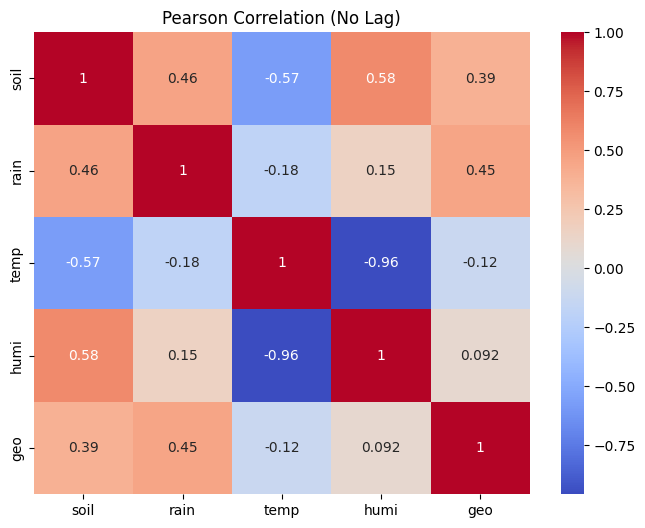

In [143]:
corr_matrix = df_val[feature_cols]
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix.corr(), annot=True, cmap='coolwarm')
plt.title("Pearson Correlation (No Lag)")
plt.show()

In [144]:
def lag_corr(x, y, max_lag=window_size*10):
    lags = []
    corrs = []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            corr = np.corrcoef(x[:lag], y[-lag:])[0, 1]
        elif lag > 0:
            corr = np.corrcoef(x[lag:], y[:-lag])[0, 1]
        else:
            corr = np.corrcoef(x, y)[0, 1]
        lags.append(lag)
        corrs.append(corr)
    return lags, corrs


/tmp/ipython-input-1202832202.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df_val['rain'].fillna(method='ffill').values
/tmp/ipython-input-1202832202.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df_val['soil'].fillna(method='ffill').values


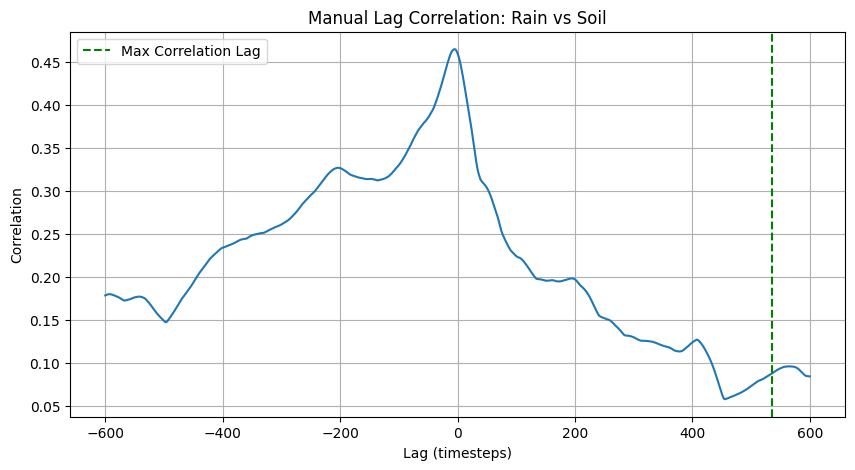

In [145]:
x = df_val['rain'].fillna(method='ffill').values
y = df_val['soil'].fillna(method='ffill').values
lags, corrs = lag_corr(x, y, max_lag=window_size*10)

plt.figure(figsize=(10, 5))
plt.plot(lags, corrs)
plt.axvline(x=np.argmax(corrs) - 60, color='green', linestyle='--', label='Max Correlation Lag')
plt.title("Manual Lag Correlation: Rain vs Soil")
plt.xlabel("Lag (timesteps)")
plt.ylabel("Correlation")
plt.grid(True)
plt.legend()
plt.show()


/tmp/ipython-input-3179048846.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df_val['rain'].fillna(method='ffill').values
/tmp/ipython-input-3179048846.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df_val['soil'].fillna(method='ffill').values


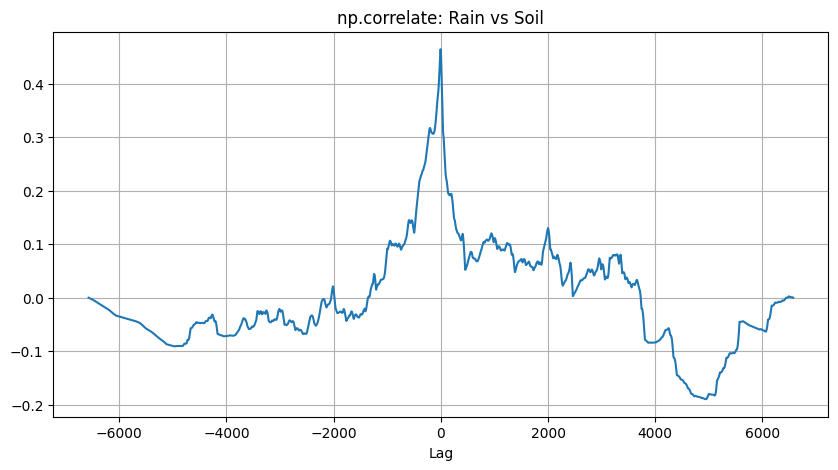

In [146]:
x = df_val['rain'].fillna(method='ffill').values
y = df_val['soil'].fillna(method='ffill').values

x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

corr = np.correlate(x, y, mode='full') / len(x)
lags = np.arange(-len(x)+1, len(x))

plt.figure(figsize=(10,5))
plt.plot(lags, corr)
plt.title("np.correlate: Rain vs Soil")
plt.xlabel("Lag")
plt.grid(True)
plt.show()


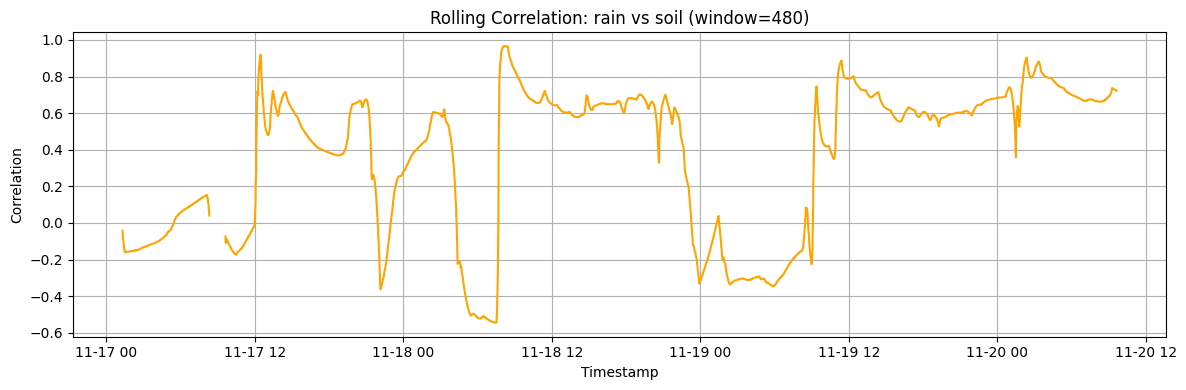

In [147]:
# ตัวอย่าง: ถ้า sampling ทุก 10 นาที → 48 จุด = 8 ชั่วโมง
df = df_val.copy()
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

rolling_corr = df['rain'].rolling(window_size*8).corr(df['soil'])

plt.figure(figsize=(12, 4))
plt.plot(df['Timestamp'], rolling_corr, color='orange')
plt.title(f"Rolling Correlation: rain vs soil (window={window_size*8})")
plt.xlabel("Timestamp")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

## histogram

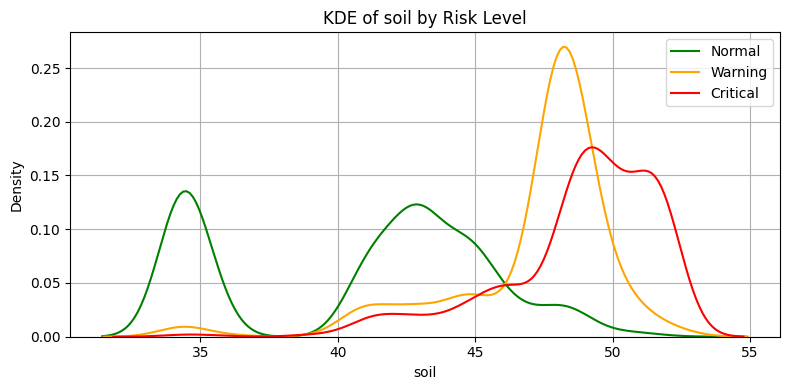

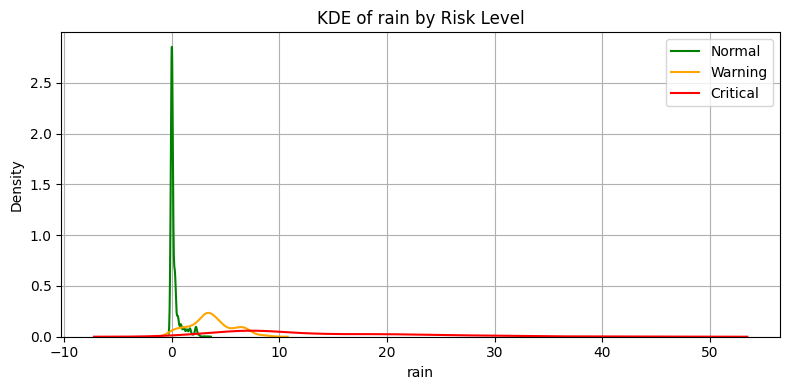

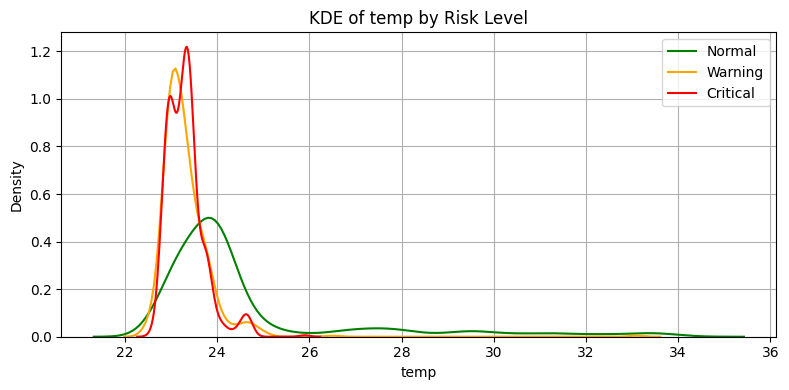

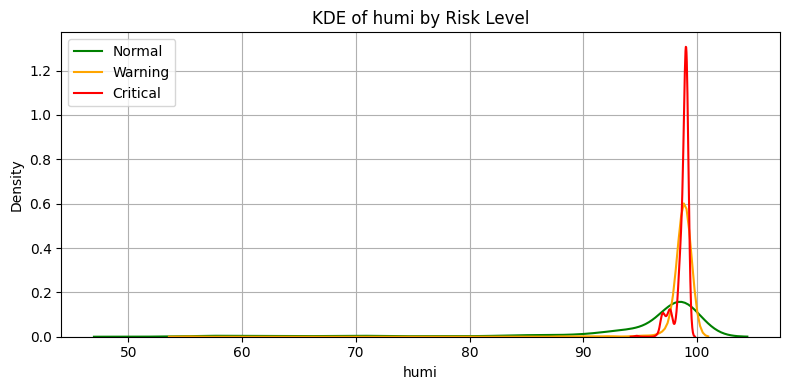

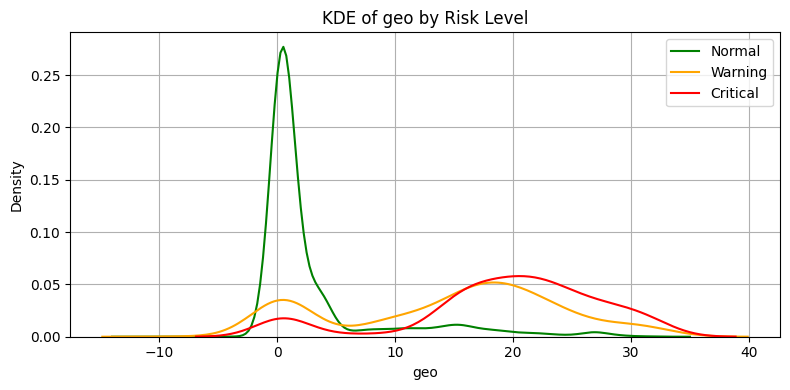

In [148]:
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df_val[df_val['predicted_risk'] == 'Normal'][col], label='Normal', color='green')
    sns.kdeplot(df_val[df_val['predicted_risk'] == 'Warning'][col], label='Warning', color='orange')
    sns.kdeplot(df_val[df_val['predicted_risk'] == 'Critical'][col], label='Critical', color='red')
    plt.title(f"KDE of {col} by Risk Level")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Box Plot feature by risk

/tmp/ipython-input-564551364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-564551364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-564551364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-564551364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-564551364.py:4: FutureWarning: 

Passing `palette

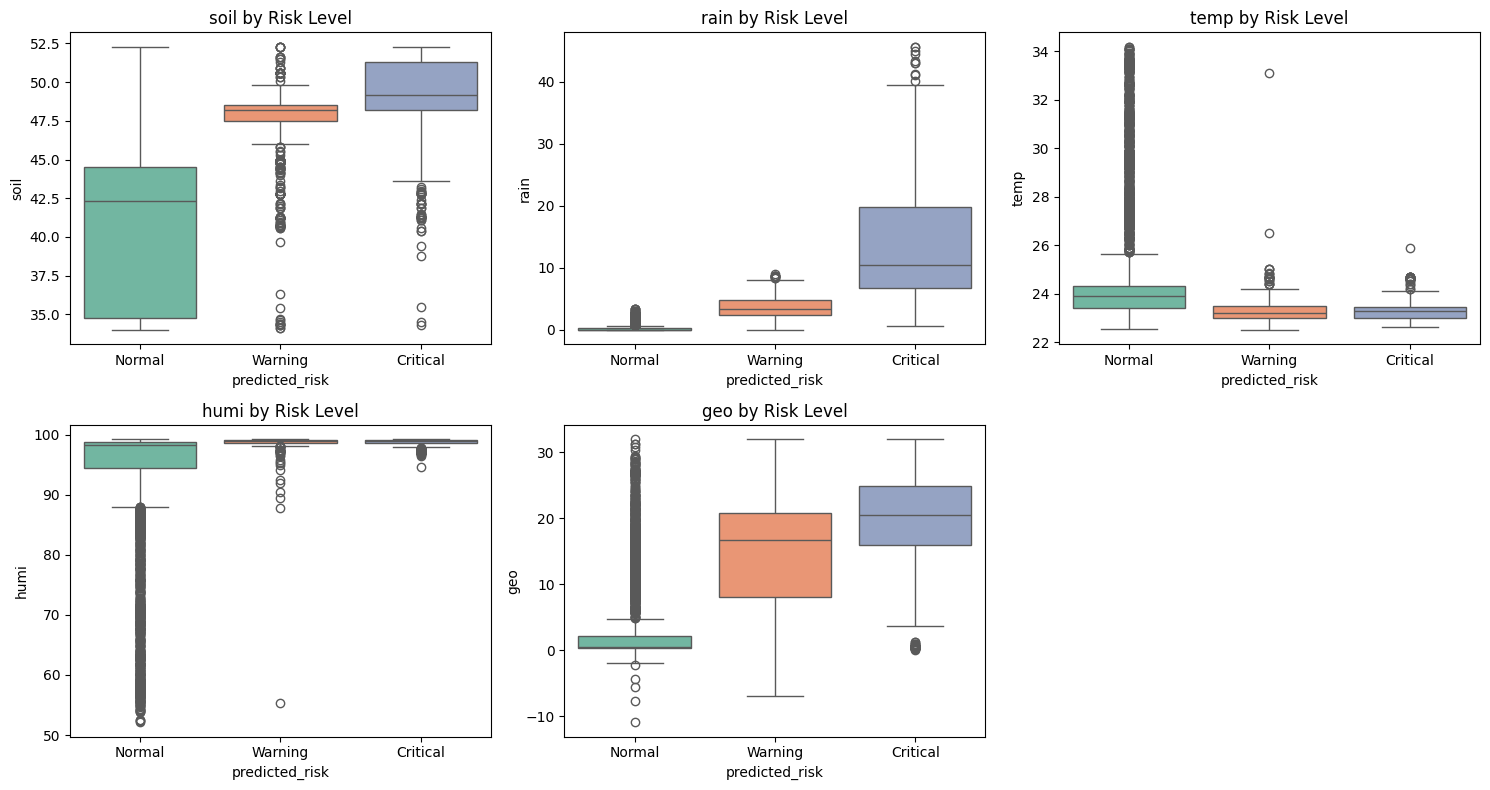

In [149]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(feature_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(
        x='predicted_risk',
        y=col,
        data=df_val,
        order=['Normal', 'Warning', 'Critical'],  # 🔧 fix order here
        palette='Set2'
    )
    plt.title(f'{col} by Risk Level')
plt.tight_layout()
plt.show()


## Time Series

In [150]:
df['Timestamp'].min()

Timestamp('2025-11-16 11:12:00')

In [151]:
df['Timestamp'].max()

Timestamp('2025-11-20 09:37:00')

In [152]:
if 'timestamp' in df_val.columns:
    df_val['timestamp'] = pd.to_datetime(df_val['timestamp'])
    df_val_sorted = df_val.sort_values('timestamp')

    plt.figure(figsize=(12,5))
    plt.plot(df_val_sorted['timestamp'], df_val_sorted['anomaly_score'], color='black', label='Anomaly Score')
    plt.axhline(warn_thresh, color='orange', linestyle='--', label='Warning')
    plt.axhline(crit_thresh, color='red', linestyle='--', label='Critical')
    plt.title('Anomaly Score over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

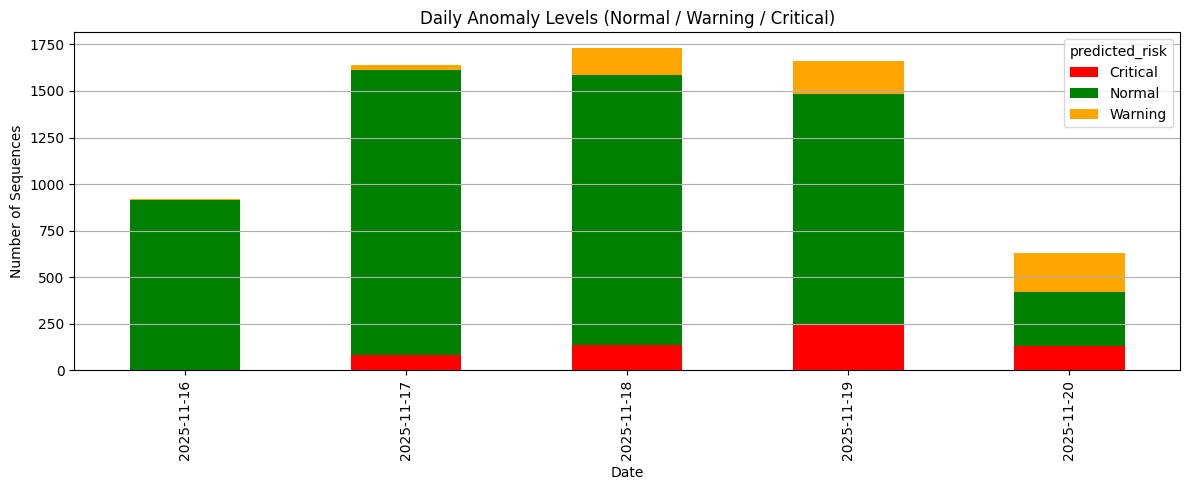

In [153]:

df_results = df_val
df_results['date'] = pd.to_datetime(df_results['Timestamp']).dt.date

risk_order = ['Critical', 'Normal', 'Warning']

alerts_per_day = df_results.groupby(['date', 'predicted_risk']).size().unstack(fill_value=0)

for risk in risk_order:
    if risk not in alerts_per_day.columns:
        alerts_per_day[risk] = 0

alerts_per_day = alerts_per_day[risk_order]

colors = ['red', 'green', 'orange']

alerts_per_day.plot(kind='bar', stacked=True, figsize=(12,5), color=colors)

plt.title("Daily Anomaly Levels (Normal / Warning / Critical)")
plt.xlabel("Date")
plt.ylabel("Number of Sequences")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


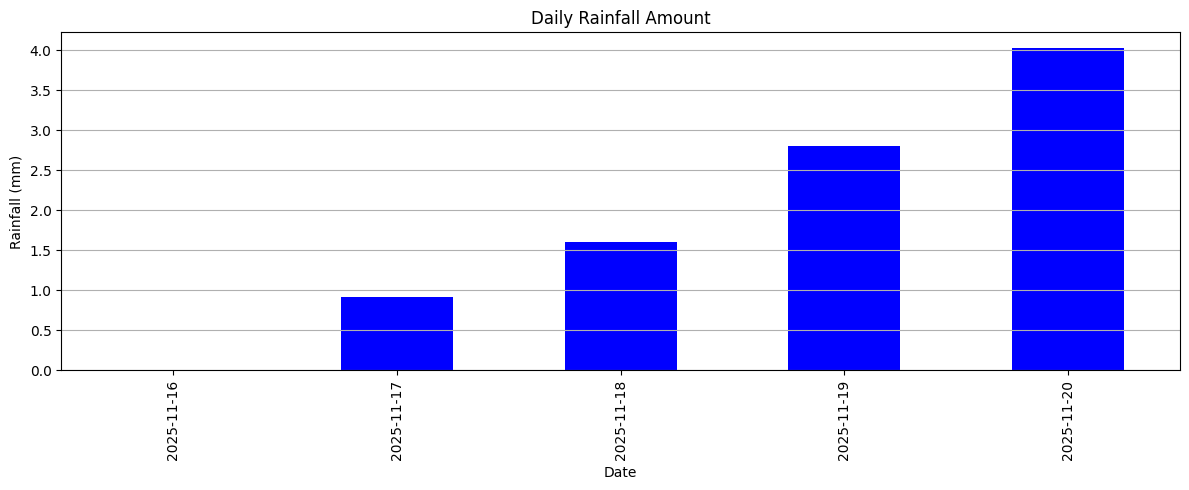

In [154]:

# สมมติ df_rain มี 'timestamp' และ 'rain_amount'

df_results['date'] = pd.to_datetime(df_results['Timestamp']).dt.date

# รวมปริมาณฝนรายวัน (sum)
rain_per_day = df_results.groupby('date')['rain'].mean()

# plot กราฟแท่งปริมาณฝนรายวัน
plt.figure(figsize=(12,5))
rain_per_day.plot(kind='bar', color='blue')

plt.title("Daily Rainfall Amount")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


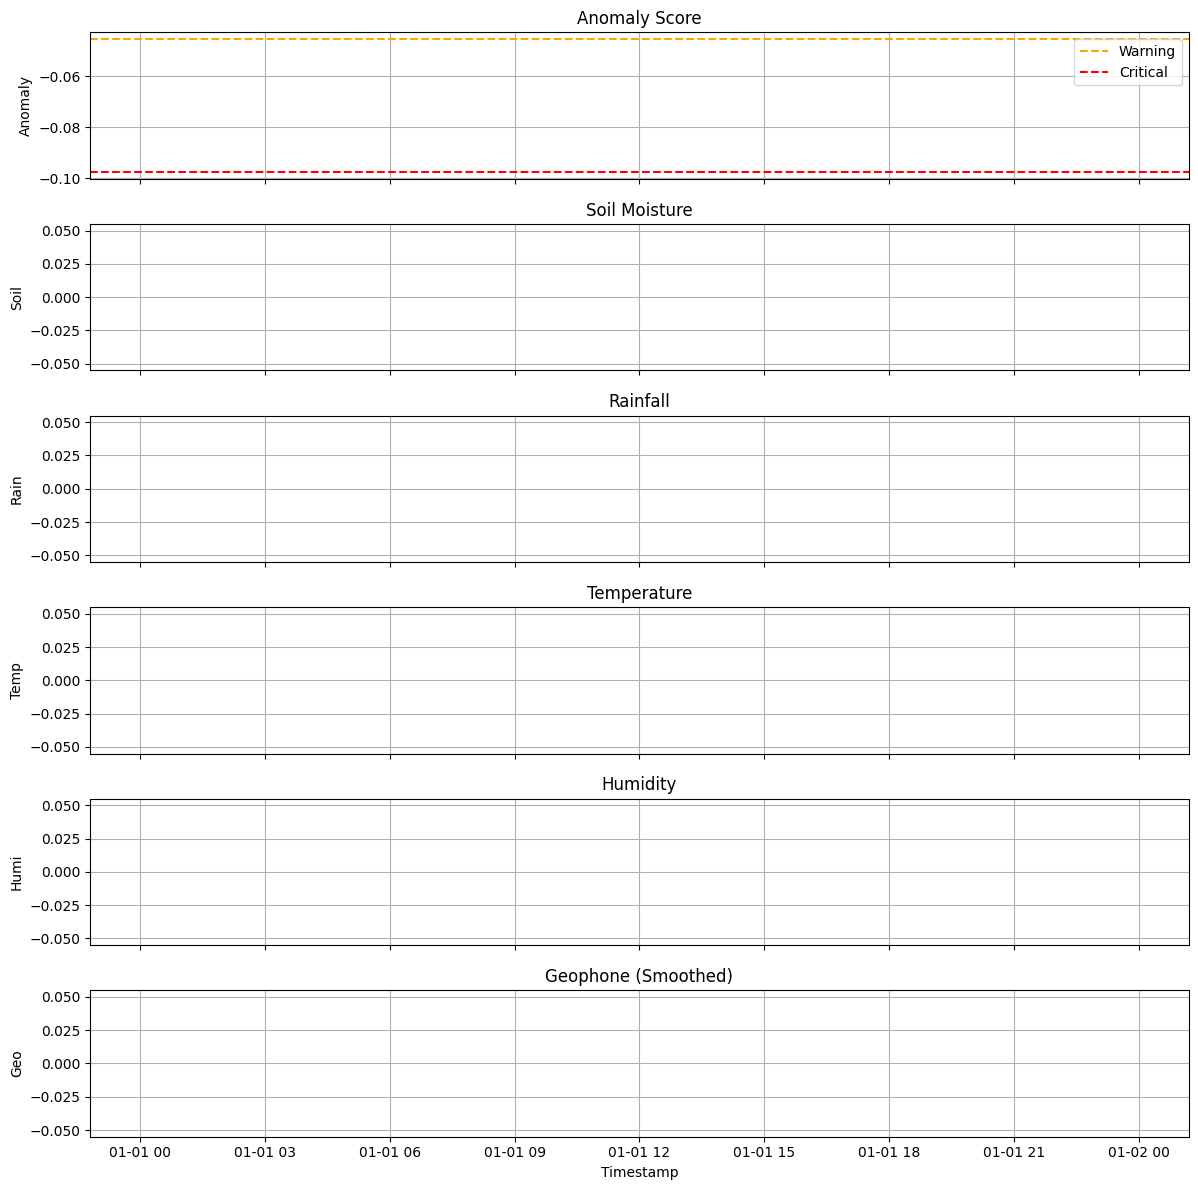

In [105]:
df_val['Timestamp'] = pd.to_datetime(df_val['Timestamp'])
df_dev = df_val.set_index('Timestamp').sort_index()
#df_dev = df_dev[df_dev['devID'] == 101.0]
df_range = df_dev.loc["2025-11-05":"2025-11-07"]

# สร้าง subplot 6 แถว
fig, axs = plt.subplots(6, 1, figsize=(12, 12), sharex=True)

# Plot 1: Anomaly Score
axs[0].scatter(df_range.index, df_range['anomaly_score'], color='green', s=15)
axs[0].axhline(y=warn_thresh, color='orange', linestyle='--', label='Warning')
axs[0].axhline(y=crit_thresh, color='red', linestyle='--', label='Critical')
axs[0].set_ylabel("Anomaly")
axs[0].set_title("Anomaly Score")
axs[0].legend()
axs[0].grid(True)

# Plot 2: Soil
axs[1].plot(df_range.index, df_range['soil'], color='saddlebrown')
axs[1].set_ylabel("Soil")
axs[1].set_title("Soil Moisture")
axs[1].grid(True)

# Plot 3: Rain
axs[2].plot(df_range.index, df_range['rain'], color='blue')
axs[2].set_ylabel("Rain")
axs[2].set_title("Rainfall")
axs[2].grid(True)

# Plot 4: Temp
axs[3].plot(df_range.index, df_range['temp'], color='red')
axs[3].set_ylabel("Temp")
axs[3].set_title("Temperature")
axs[3].grid(True)

# Plot 5: Humi
axs[4].plot(df_range.index, df_range['humi'], color='purple')
axs[4].set_ylabel("Humi")
axs[4].set_title("Humidity")
axs[4].grid(True)

window_size = 20  # ลองปรับค่าตามความเหมาะสม เช่น 10, 50, 100
smoothed_geo = df_range['geo'].rolling(window=window_size).mean()

axs[5].plot(df_range.index, smoothed_geo, color='black')
axs[5].set_ylabel("Geo")
axs[5].set_title("Geophone (Smoothed)")
axs[5].grid(True)

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

# F1-score

In [106]:
df_val["predicted_risk"].value_counts()

,count
predicted_risk,
Normal,5417
Critical,594
Warning,563


In [107]:
df_val["label"].value_counts()

,count
label,
normal,5469
warning,621
critical,484


In [108]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix

df_val["label"] = df_val["label"].fillna("Normal")

# 1.2 ปรับข้อความให้เป็นตัวพิมพ์เล็กทั้งหมด (Lowercase) เพื่อให้เทียบกันได้
# เช่น 'Normal' จะตรงกับ 'normal', 'Warning' ตรงกับ 'warning'
df_val["predicted_risk"] = df_val["predicted_risk"].str.lower().str.strip()
df_val["label"] = df_val["label"].str.lower().str.strip()

# ---------------------------------------------------------
# 2. คำนวณ F1 Score
# ---------------------------------------------------------

y_true = df_val["label"]          # ค่าจริง
y_pred = df_val["predicted_risk"] # ค่าที่โมเดลทำนาย

# กำหนดลำดับ Class เพื่อให้แสดงผลสวยงาม (เรียงตามความรุนแรง)
target_names = ['normal', 'warning', 'critical']

print("------- Classification Report (F1 Score) -------")
# คำสั่งนี้จะคำนวณ Precision, Recall, และ F1-score ให้ครบทุก Class
print(classification_report(y_true, y_pred, labels=target_names))

print("\n------- Confusion Matrix -------")
# ดูว่าทำนายถูก/ผิด ไปตกที่ช่องไหนบ้าง
cm = confusion_matrix(y_true, y_pred, labels=target_names)
df_cm = pd.DataFrame(cm, index=[f"Actual {c}" for c in target_names],
                         columns=[f"Pred {c}" for c in target_names])
print(df_cm)

# ---------------------------------------------------------
# 3. ถ้าต้องการค่า F1 Score ตัวเดียว (Macro หรือ Weighted)
# ---------------------------------------------------------
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"\nMacro F1 Score: {f1_macro:.4f}")

------- Classification Report (F1 Score) -------
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      5469
     warning       0.86      0.78      0.82       621
    critical       0.77      0.94      0.84       484

    accuracy                           0.96      6574
   macro avg       0.87      0.90      0.88      6574
weighted avg       0.97      0.96      0.96      6574


------- Confusion Matrix -------
                 Pred normal  Pred warning  Pred critical
Actual normal           5402            51             16
Actual warning            15           483            123
Actual critical            0            29            455

Macro F1 Score: 0.8842


In [155]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix

df_val["label"] = df_val["label"].fillna("Normal")

# 1.2 ปรับข้อความให้เป็นตัวพิมพ์เล็กทั้งหมด (Lowercase) เพื่อให้เทียบกันได้
# เช่น 'Normal' จะตรงกับ 'normal', 'Warning' ตรงกับ 'warning'
df_val["predicted_risk"] = df_val["predicted_risk"].str.lower().str.strip()
df_val["label"] = df_val["label"].str.lower().str.strip()

# ---------------------------------------------------------
# 2. คำนวณ F1 Score
# ---------------------------------------------------------

y_true = df_val["label"]          # ค่าจริง
y_pred = df_val["predicted_risk"] # ค่าที่โมเดลทำนาย

# กำหนดลำดับ Class เพื่อให้แสดงผลสวยงาม (เรียงตามความรุนแรง)
target_names = ['normal', 'warning', 'critical']

print("------- Classification Report (F1 Score) -------")
# คำสั่งนี้จะคำนวณ Precision, Recall, และ F1-score ให้ครบทุก Class
print(classification_report(y_true, y_pred, labels=target_names))

print("\n------- Confusion Matrix -------")
# ดูว่าทำนายถูก/ผิด ไปตกที่ช่องไหนบ้าง
cm = confusion_matrix(y_true, y_pred, labels=target_names)
df_cm = pd.DataFrame(cm, index=[f"Actual {c}" for c in target_names],
                         columns=[f"Pred {c}" for c in target_names])
print(df_cm)

# ---------------------------------------------------------
# 3. ถ้าต้องการค่า F1 Score ตัวเดียว (Macro หรือ Weighted)
# ---------------------------------------------------------
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"\nMacro F1 Score: {f1_macro:.4f}")

------- Classification Report (F1 Score) -------
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      5469
     warning       0.86      0.78      0.82       621
    critical       0.77      0.94      0.84       484

    accuracy                           0.96      6574
   macro avg       0.87      0.90      0.88      6574
weighted avg       0.97      0.96      0.96      6574


------- Confusion Matrix -------
                 Pred normal  Pred warning  Pred critical
Actual normal           5402            51             16
Actual warning            15           483            123
Actual critical            0            29            455

Macro F1 Score: 0.8842


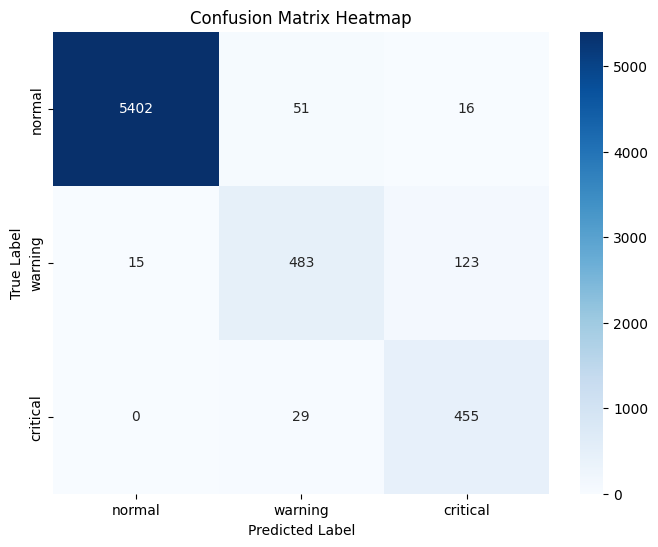

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()